# Lab 08: Normal Distribution and Variance of Sample Means

Welcome to Lab 08.

In today's lab, we will learn about [the variance of sample means](https://inferentialthinking.com/chapters/14/5/Variability_of_the_Sample_Mean.html) as well as [the normal distribution](https://www.inferentialthinking.com/chapters/14/3/SD_and_the_Normal_Curve.html).

<div style="background-color:#f2d8b2; border-left:6px solid #b36a00; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>ℹ️ Appropriate collaboration and AI usage</b><br>
<span style="font-size:0.9em;">You are welcome to collaborate with other students on this lab, as long as each student writes their own solutions. Consult with your teacher and course syllabus for information and policies regarding appropriate use of AI tools and submission of late work.</span>
</div>

In [1]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
import math
from datascience import *

# These lines do some fancy plotting.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# 1. Normal Distributions

When we visualize the distribution of a sample, we are often interested in the mean and the standard deviation of the sample (for the rest of this lab, we will abbreviate “standard deviation” as “SD”). These two summary statistics can give us a bird’s eye view of the distribution - by letting us know where the distribution sits on the number line and how spread out it is, respectively. 

### Question 1.1.
The next cell loads the table `births` which you likely studied earlier in this course. This is a large random sample of US births and includes information about mother-child pairs. 

Plot the **distribution** of mother's ages from the table. Don't change the last line of code, which will automatically plot the mean value of the sample on the distribution as a red triangle.

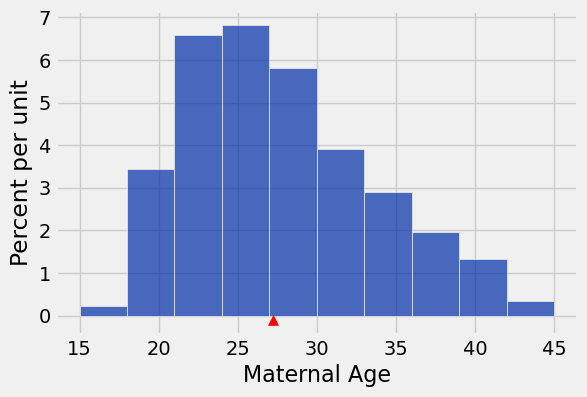

In [2]:
births = Table().read_table('baby.csv')
births.hist('Maternal Age') # SOLUTION

# Do not change this line
plt.scatter(np.mean(births.column('Maternal Age')), -0.001, color = 'red', s = 50 , marker = "^");

From the plot above, we can see that the mean is the center of gravity, or balance point, of the distribution. If you cut the distribution out of cardboard, and then placed your finger on the number line at the location of mean, the distribution would perfectly balance on your finger. This might seem counter-intuitive since **the distribution is not symmetrical** (the distribution above is right skewed, which means it has a long right tail) but it would still balance at the mean!

### Question 1.2.
Given that the distribution in the previous question is right skewed, which of the following statements is true? 

1. The mean is equal to the median.
2. The mean is greater than the median.
3. The mean is less than the median.

Assign `mean_median` to one of the corresponding integers.

In [3]:
mean_median = 2 # SOLUTION

In [4]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `mean_median` is a valid choice
failure_message: ❌ `mean_median` has not been assigned a valid choice of 1, 2, or 3
""" # END TEST CONFIG

mean_median in [1,2,3]

True

In [5]:
""" # BEGIN TEST CONFIG
hidden: true
points: 1
""" # END TEST CONFIG

mean_median == 2

True

We are also interested in the standard deviation of mother's ages. The SD gives us a sense of how variable mothers' ages are around the average mothers' age. If the SD is large, then the mothers' ages should spread over a large range from the mean. If the SD is small, then the mothers' ages should be tightly clustered around the average mother's age. 

**Reminder**: The SD of an array is defined as the root mean square of deviations, where deviations are the difference between each element in the array and the average value of the array.

**Fun fact**: $\sigma$ (lowercase Greek letter sigma) is used to represent the SD of a population and  $\mu$ (lowercase Greek letter mu) is used to represent the mean of a population.

### Question 1.3.
Complete the cell below to calculate the mean and SD of `Maternal Age`. Assign these values to `age_mean` and `age_sd` respectively. 

Then, run the cell to see blue triangles that are one SD away from the sample mean marked in red.


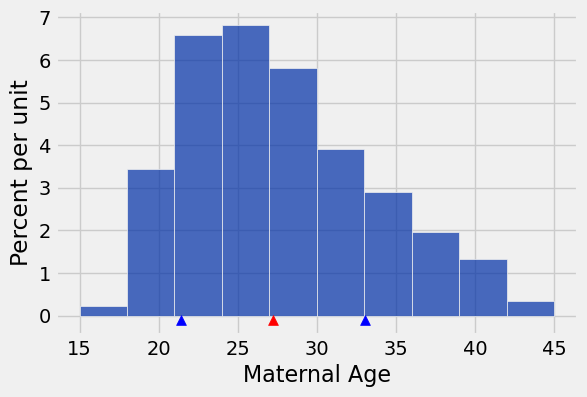

In [6]:
age_mean = np.mean(births.column('Maternal Age')) # SOLUTION
age_sd = np.std(births.column('Maternal Age')) # SOLUTION
births.hist('Maternal Age')

plt.scatter(age_mean, -0.001, color = 'red', s = 50, marker = '^');
plt.scatter(age_mean + age_sd, -0.001, marker = '^', color = 'blue', s = 50);
plt.scatter(age_mean - age_sd, -0.001, marker = '^', color = 'blue', s = 50);

In [7]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `age_mean` and `age_sd` are reasonable values
failure_message: ❌ The values of either `age_mean` or `age_sd` (or both) are not reasonable for this dataset
""" # END TEST CONFIG

age_mean < 100 and age_sd < 10

True

In [8]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.5
""" # END TEST CONFIG

np.isclose(age_mean, 27.228279386712096)

True

In [9]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.5
""" # END TEST CONFIG

np.isclose(age_sd, 5.8153604041908968)

True

### Normal distributions

In the histogram above, the standard deviation is not easy to identify just by looking at the graph.

However, the distributions of some variables allow us to easily spot the standard deviation from the histogram. Specifically, if a sample follows a **normal distribution**, the standard deviation is easily spotted at the point of inflection (the point where the curve begins to change the direction of its curvature) of the distribution.

### Question 1.4.
Fill in the following code to calculate the mean and standard deviation of maternal heights, which **are** roughly normally distributed. Then, run the provided code to plot the standard deviation on the histogram, as before - **notice where one standard deviation (blue) away from the mean (red) falls on the plot.** You should hopefully see that if you overlaid the curve for this distribution, the standard deviation markings would be aligned with the inflection points of the curve.

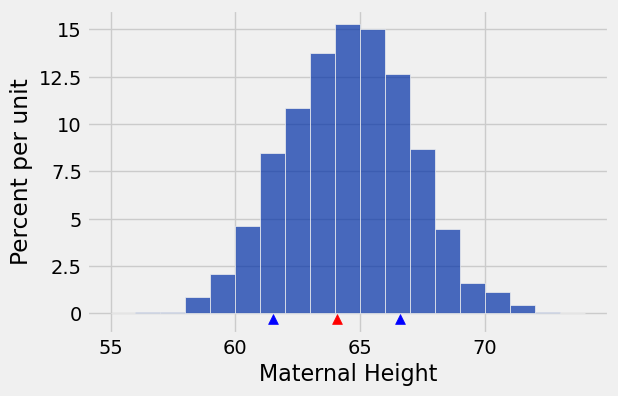

In [10]:
height_mean = np.mean(births.column('Maternal Height')) # SOLUTION
height_sd = np.std(births.column('Maternal Height')) # SOLUTION
births.hist('Maternal Height', bins = np.arange(55,75,1))

plt.scatter((height_mean), -0.003, color = 'red', s = 50, marker = '^');
plt.scatter(height_mean + height_sd, -0.003, marker = '^', color = 'blue', s = 50);
plt.scatter(height_mean - height_sd, -0.003, marker = '^', color = 'blue', s = 50);

In [11]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `height_mean` and `height_sd` are reasonable values
failure_message: ❌ The values of either `height_mean` or `height_sd` (or both) are not reasonable for this dataset
""" # END TEST CONFIG

height_mean < 100 and height_sd < 10

True

In [12]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.5
""" # END TEST CONFIG

np.isclose(height_mean, 64.049403747870528)

True

In [13]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.5
""" # END TEST CONFIG

np.isclose(height_sd, 2.5250254409674375)

True

### Central Limit Theorem

We don’t always know how a variable will be distributed, and making assumptions about whether or not a variable will follow a normal distribution is dangerous. However, the **Central Limit Theorem** defines one distribution that *always* follows a normal distribution. **The distribution of the *sums* and *means* of many large random samples drawn with replacement from a single distribution (regardless of the distribution's original shape) will be normally distributed.**

**Remember:** the Central Limit Theorem refers to the distribution of a *statistic* calculated from a distribution, not the distribution of the original sample or population.

The next section will explore distributions of one such statistic, the sample mean.

# 2. Variability of the Sample Mean

As mentioned in the previous section, the [Central Limit Theorem](https://www.inferentialthinking.com/chapters/14/4/Central_Limit_Theorem.html) guarantees that the probability distribution of the mean of a large random sample will be roughly normal. The bell shaped curve of the sample means will be centered at the mean of the population. Due to chance, some of the sample means are higher than the population mean and some will be lower, but the deviations from the population mean are roughly symmetric on either side, as we have seen repeatedly. Formally, probability theory shows that the sample mean is an **unbiased estimate** of the population mean.

In our simulations, we also noticed that the means of larger samples tend to be more tightly clustered around the population mean than means of smaller samples. In this section, we will quantify the [variability of the sample mean](https://www.inferentialthinking.com/chapters/14/5/Variability_of_the_Sample_Mean.html) and develop a relation between the variability and the sample size.

Let's take a look at the salaries of employees of the UNC System in 2021.

**Note:** If you get stuck on any part of this lab, please refer to [Chapter 14 of the textbook](https://www.inferentialthinking.com/chapters/14/Why_the_Mean_Matters.html).

In [14]:
salaries = Table().read_table('unc_salaries_2021.csv').select('EMPLOYEE ANNUAL BASE SALARY').relabel('EMPLOYEE ANNUAL BASE SALARY','salary')
salaries

salary
49507
23558
47000
36000
31200
68945
53542
51504
35484
110000


Running the cell below will calculate the mean salary from the 2021 dataset. Since this dataset encompasses **every** UNC employee, we can consider it our population.

In [15]:
salary_mean = np.mean(salaries.column('salary'))
print('Mean salary of UNC System employees in 2021 was', round(salary_mean, 2))

Mean salary of UNC System employees in 2021 was 75617.39


Running the cell below will show the distribution of salaries for UNC System employees and show the population mean marked with a red triangle.

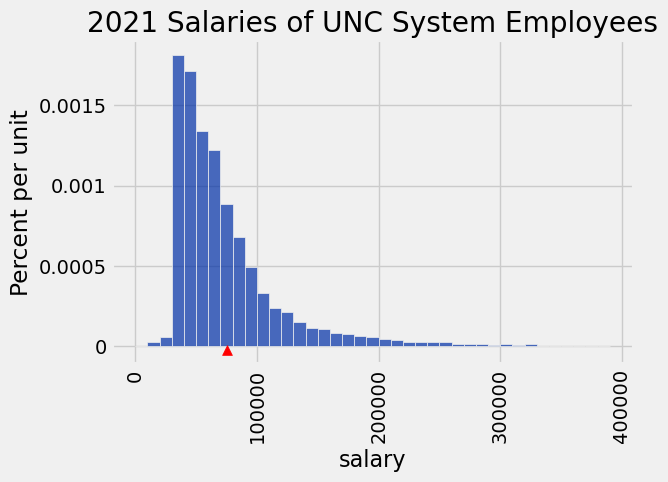

In [16]:
salaries.hist('salary', bins = np.arange(0, 400000, 10000))
plt.scatter(salary_mean, -0.0000002, marker = '^', color = 'red', s = 50);
plt.title('2021 Salaries of UNC System Employees');

Clearly, this population does not follow a normal distribution due to the large percentage of UNC System employees that earn less than $60,000. Keep that in mind as we progress through these exercises.

In this question we will take random samples **without replacement**, compute the mean value of each sample, and visually inspect the distribution of the sample means. The goal will be to investigate how the size of the sample that we take impacts the distribution of the sample means. 

Throughout this problem, remember, this is an investigation to **uncover a pattern between sample size and the distribution of sample means**. If all you were interested in was computing the average salary of a UNC System employee, this would be unnecessary since we have the entire dataset and have already computed this value! This series of questions is to help us better understand how the choice of the sample size will impact the analysis we could conduct from a sample from a population for which it is impossible to compile a complete dataset.

### Question 2.1.
Define a function `one_sample_mean`. Its arguments are:
* `table`: a Table object,
* `label`: a string object that specifies a label of a column found in `table`, and
* `sample size`: an integer that specifies the size of the sample to take from `table`

It should sample without replacement from `table`, and return the mean of the column specified by `label`.

For example, running `one_sample_mean(salaries, 'salary', 100)` should draw one random sample of size 100 from the `salaries` table and return the average value of the `salary` column of that sample.

In [17]:
def one_sample_mean(table, label, sample_size):
    # BEGIN SOLUTION NO PROMPT
    new_sample = table.sample(sample_size, with_replacement=False)
    new_sample_mean = np.mean(new_sample.column(label))
    return new_sample_mean
    # END SOLUTION
    """ # BEGIN PROMPT
    ...
    """; # END PROMPT

In [18]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `one_sample_mean` returns a `float`
failure_message: ❌ `one_sample_mean` does not return a `float`
""" # END TEST CONFIG

isinstance(one_sample_mean(salaries, 'salary', 100), (float, np.floating))

True

In [19]:
""" # BEGIN TEST CONFIG
hidden: false
points: 1
success_message: ✅ `one_sample_mean(salaries, 'salary', 100)` returns correct values
failure_message: ❌ `one_sample_mean(salaries, 'salary', 100)` does not return correct values
""" # END TEST CONFIG

np.random.seed(1219)
np.isclose(one_sample_mean(salaries, 'salary', 100), 75197.478799999997)

True

### Question 2.2.

Since the goal is to investigate how both the size of a sample and the number of samples impact the variability of the sample mean, write a function `simulate_sample_mean` which will allow you to specify these details of the simulation. The arguments of the function `simulate_sample_mean` are:

* `table`: a Table object,
* `label`: a string that denotes the label of the column in `table` that contains the variable of interest,
* `sample_size`: an integer that denotes the sample size in each simulation, and
* `repetitions`: an integer that denotes the number of sample means to generate

**Complete the code inside the `for` loop** so that it generates a sample without replacement, computes the mean of the sample, and then appends each mean to the array `means` that the provided code initializes for you.

The remainder of the provided code in the function will:
* create a table named `sample_means` out of the array named `means`,
* compute and display some statistics about the simulated sample means, and
* display a histogram of the distribution of sample means.
* return a single value: the standard deviation of the sample means.

This one function will do a lot to speed up the investigation.

In [20]:
def simulate_sample_mean(table, label, sample_size, repetitions):
    means = make_array()
    
    for i in np.arange(repetitions):
        new_sample_mean = one_sample_mean(table, label, sample_size) # SOLUTION
        means = np.append(means, new_sample_mean) # SOLUTION
    
    # Display empirical histogram and print all relevant quantities – don't change this!
    sample_means = Table().with_column('Sample Means', means)
    sample_means.hist(bins = 20)
    plt.xlabel('Sample Means')
    plt.title('Sample Size ' + str(sample_size))
    print('Sample size: \t\t\t', sample_size)
    print('Population mean: \t\t', np.mean(table.column(label)))
    print('Average of sample means: \t', np.mean(means))
    print('Population SD: \t\t\t', np.std(table.column(label)))
    print('SD of sample means: \t\t', np.std(means))
    return np.std(means)

#### Testing `simulate_sample_mean`
In the following cell, the code will use your `simulate_sample_mean` function to create 10,000 samples, each of size 100, from `salaries`, compute the sample mean for each sample, display the statistics about those sample means, then create a histogram so you can see how those sample means are distributed. If any of those steps don't seem to be working correctly, reach out to a classmate or instructor to help sort out the issue. 

**Important:** The rest of the lab requires this function to be working correctly, so make sure that everything is working as intended before moving on!

Sample size: 			 100
Population mean: 		 75617.3902692
Average of sample means: 	 75513.3704638
Population SD: 			 56667.4784864
SD of sample means: 		 5692.67924175


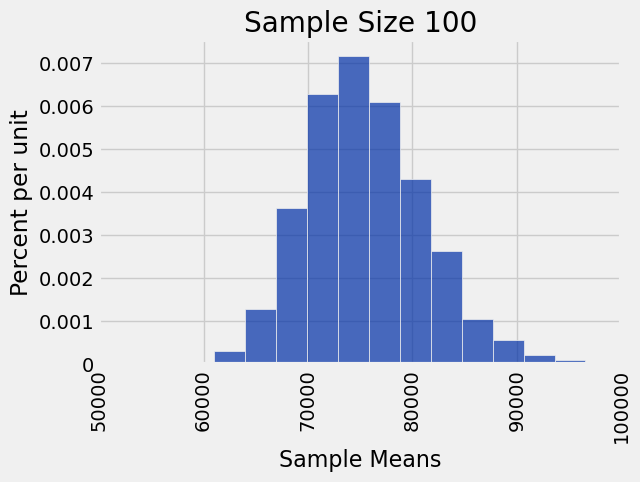

In [21]:
simulate_sample_mean(salaries, 'salary', 100, 10000)
# This line of code sets the axes to be between 50,000 and 100,000 after it's been created
plt.xlim(50000, 100000);

### Size of samples

Let's first use `simulate_sample_mean` to investigate how the sample size may impact the distribution of the sample means for the `'salary'` column in the `salaries` Table.

### Question 2.3.a
Keep the number of simulations fixed at 10,000 but vary the sample size. Suggested sample sizes: 100, 250, 500, and 1000, but feel free to try your own! The next question will ask you to summarize what you've observed when changing the sample size, so take note of the statistics as well as the histograms to use in your response.

**Note:** Don't worry about the `plots.xlim()` line – it just makes sure that all of the plots generated in this section have the same x-axis, ranging from 50,000 to 100,000. 

Sample size: 			 400
Population mean: 		 75617.3902692
Average of sample means: 	 75581.6079716
Population SD: 			 56667.4784864
SD of sample means: 		 2783.96955606


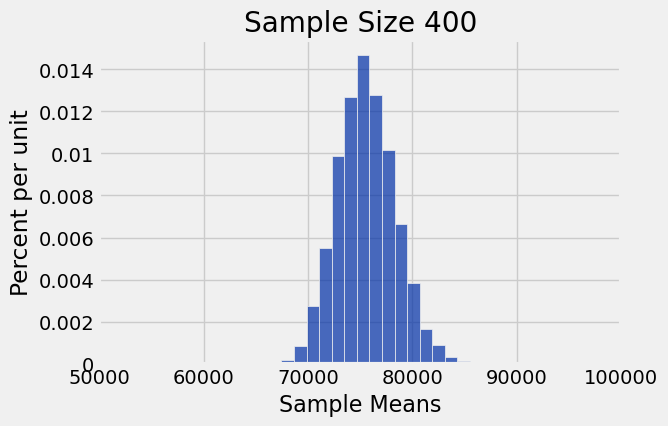

In [22]:
# BEGIN SOLUTION NO PROMPT
simulate_sample_mean(salaries, 'salary', 400, 10000)
plt.xlim(50000, 100000);
# END SOLUTION
""" # BEGIN PROMPT
simulate_sample_mean(..., ..., ..., ...)
plt.xlim(50000, 100000);
"""; # END PROMPT

### Question 2.3.b

Describe what you observed while changing the sample size in your investigation. Your response should describe
how the sample size impacts, if at all, the distribution of the sample means. Use specific values of statistics that were computed, as well as visual characteristics of the histograms that were generated in your investigation in your response.

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION**: As the sample size increases, the SD of sample means should tend to decrease, but all other statistics should remain the same. The histograms generated should all be centered around the population mean, but as the sample size increases the width of the distribution should narrow since there is less variability in the sample means.

### Question 2.4.
Take a moment and compare the histograms that you generated in 2.3a, as well as the Central Limit Theorem (CLT) and Law of Averages. Then, use the `make_array` function to assign an array of numbers corresponding to those statements below that are TRUE, to `q2_4`.

1. We see the [Central Limit Theorem (CLT)](https://inferentialthinking.com/chapters/14/4/Central_Limit_Theorem.html) in action because the distributions of the sample means are bell-shaped.
2. We see the [Law of Averages](https://inferentialthinking.com/chapters/10/1/Empirical_Distributions.html#the-law-of-averages) in action because the distributions of the sample means look like the distribution of the population.
3. One of the conditions for CLT is that we have to draw a small random sample with replacement from the population.
4. One of the conditions for CLT is that we have to draw a large random sample with replacement from the population.
5. One of the conditions for CLT is that the population must be normally distributed.
6. All plots in 2.3a are roughly centered around the population mean.
7. All plots in 2.3a are roughly centered around the mean of the first generated sample.

In [23]:
q2_4 = make_array(1, 4, 6) # SOLUTION

In [24]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `q2_4` contains valid choices
failure_message: ❌ `q2_4` contains at least one invalid choice
""" # END TEST CONFIG

set(q2_4).issubset(set([1,2,3,4,5,6,7]))

True

In [25]:
""" # BEGIN TEST CONFIG
hidden: true
points: 1
""" # END TEST CONFIG

set(q2_4) == set([1, 4, 6])

True

### Number of Samples

Let's now use `simulate_sample_mean` to investigate how the number of samples may impact the distribution of the sample means for the `'salary'` column in the `salaries` Table.

### Question 2.5.a

Keep the sample size fixed at 100, but vary the number of samples. Suggested number of samples: 500, 1000, 5000, and 10000, but feel free to try your own! The next question will ask you to summarize what you've observed when changing the number of samples, so take note of the statistics as well as the histograms to use in your response.

Sample size: 			 100
Population mean: 		 75617.3902692
Average of sample means: 	 75991.7327758
Population SD: 			 56667.4784864
SD of sample means: 		 6046.44299804


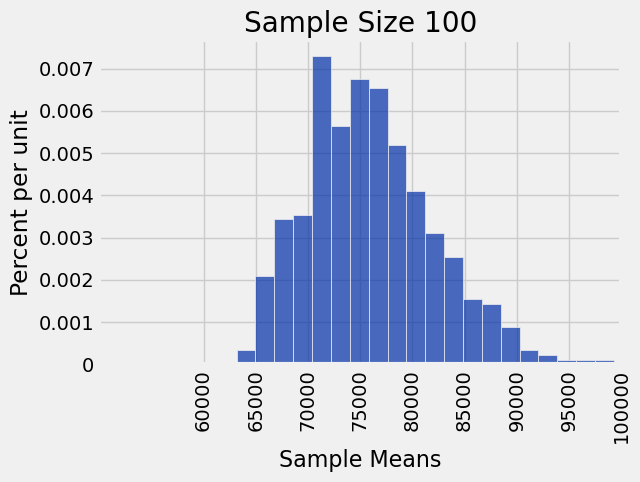

In [26]:
# BEGIN SOLUTION NO PROMPT
simulate_sample_mean(salaries, 'salary', 100, 500)
plt.xlim(50000, 100000);
# END SOLUTION
""" # BEGIN PROMPT
simulate_sample_mean(..., ..., ..., ...)
plt.xlim(50000, 100000);
"""; # END PROMPT

Reflect on what you've noticed about the distributions of sample means in the histograms you've generated.

### Question 2.5.b
Describe what you observed while changing the number of samples in your investigation. Your response should describe how the number of samples impacts, if at all, the distribution of the sample means. Use specific values of statistics that were computed, as well as visual characteristics of the histograms that were generated in your investigation in your response.

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION**: The distributions tend to become smoother as the number of samples increases, but the variability does not change, nor do any of the other statistics.

From these two plots, we can see that the SD of our **sample** approaches the SD of our population as our sample size increases, but the SD of our **sample means** (in other words, the variability of the sample mean) decreases as our sample size increases.

### Question 2.6.

Let's think about how the relationships between the standard deviation of a population (population SD), the standard deviation of observations in a single sample (sample SD), and the standard deviation of many sample means (SD of sample means) change with varying sample size. 

Which of the following is true? Assign an array of integer(s) to `pop_vs_sample` that correspond to the statements below that are TRUE. 

1. Sample SD gets smaller with increasing sample size.
2. Sample SD gets larger with increasing sample size.
3. Sample SD becomes more consistent with population SD with increasing sample size.
4. SD of sample means gets smaller with increasing sample size.
5. SD of sample means gets larger with increasing sample size.
6. SD of sample means stays the same with increasing sample size.

In [27]:
pop_vs_sample = make_array(3, 4) # SOLUTION

In [28]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `pop_vs_sample` contains valid choices
failure_message: ❌ `pop_vs_sample` contains at least one invalid choice
""" # END TEST CONFIG

set(pop_vs_sample).issubset(set([1,2,3,4,5,6]))

True

In [29]:
""" # BEGIN TEST CONFIG
hidden: true
points: 1
""" # END TEST CONFIG

np.array_equal(pop_vs_sample, make_array(3, 4))

True

## What about Bootstrapping?
Throughout this lab, we have been taking many random samples from a population. However, all of these principles hold for bootstrapped resamples from a single sample. 

That's it. You've completed Lab 08. There weren't many tests, but there were a lot of points at which you should've stopped and understood exactly what was going on. Consult the textbook or ask your instructor if you have any other questions.

# Submitting your work
You're done with this assignment! Assignments should be turned in using the following best practices:
1. Save your notebook.
2. Restart the kernel and run all cells up to this one.
3. Run the cell below with the code `grader.export(...)`. This will re-run all the tests. Make sure they are passing as you expect them to.
4. Download the file named `lab08_<date-time-stamp>.zip`, found in the explorer pane on the left side of the screen. **Note**: If clicking on the link in this notebook results in an error, try downloading the file from the file explorer panel on the left.
5. Upload `lab08_<date-time-stamp>.zip` to the corresponding assignment on Canvas.